# Unified Retrieval Comparison: BM25, Word2Vec, and Transformers

This notebook compares keyword, static-embedding, and contextual semantic retrieval on the same corpus and relevance judgments. It reports Recall@k, Precision@k, and MRR, inspects ranked results, and visualizes the transformer embedding space.

In [1]:
%matplotlib inline
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA

PROJECT_DIR = Path.cwd().resolve()
if PROJECT_DIR.name == 'notebooks':
    PROJECT_DIR = PROJECT_DIR.parent
sys.path.insert(0, str(PROJECT_DIR / 'src'))
sys.path.insert(0, str(PROJECT_DIR / 'streamlit'))

from bm25_retriever import BM25Retriever
from evaluator import IRMetrics
from transformer_retriever import TransformerRetriever
from word2vec_retriever import Word2VecRetriever
from data_loader import DataLoader

## Shared evaluation data

The required evaluation uses a reproducible 2,000-query sample of the BEIR **Natural Questions (NQ)** test set, loaded through the project's provided `DataLoader`. The loader keeps every relevant document for the sampled queries and converts BEIR string IDs into the sequential integer IDs expected by all three retrievers. The small TechFlow corpus remains available only for the Streamlit app demo; it is not used for this evaluation.

In [2]:
loader = DataLoader('BeIR/nq')
loader.load_dataset(split='test', query_sample_size=2000, random_seed=42)
corpus_texts, query_texts, qrels = loader.prepare_retrieval_data()
print(f'Natural Questions evaluation: {len(corpus_texts):,} documents, '
      f'{len(query_texts):,} queries, and {len(qrels):,} qrel entries')

INFO:data_loader:Loading BeIR/nq (Natural Questions) dataset using official BEIR package...


INFO:data_loader:Dataset nq already exists at /Users/mkml/Documents/work/Udacity/Build A Transformer based Q&A System/Build-a-Transformer-based-Q-A-System/starter/dataset/nq, skipping download...


INFO:data_loader:Loading test split...


INFO:beir.datasets.data_loader:Loading Corpus...


  0%|          | 0/2681468 [00:00<?, ?it/s]

...

INFO:data_loader:Converted to retrieval format:


INFO:data_loader:  - Corpus texts: 2440


INFO:data_loader:  - Query texts: 2000


INFO:data_loader:  - QRELs with sequential IDs: 2000


Natural Questions evaluation: 2,440 documents, 2,000 queries, and 2,000 qrel entries


## Metrics

- **Recall@k** is the fraction of all relevant documents found in the first *k* results.
- **Precision@k** is the fraction of the first *k* positions occupied by relevant documents.
- **MRR** averages the reciprocal rank of the first relevant result, rewarding systems that put a useful document near rank 1.

In [3]:
bm25 = BM25Retriever()
bm25.build_index(corpus_texts)
bm25_results = bm25.retrieve(query_texts, k=20)
bm25_metrics = IRMetrics.evaluate_retrieval(bm25_results, qrels)
bm25_metrics

🔧 Building BM25 index...
✅ BM25 index built for 2,440 documents
🔍 Running BM25 retrieval for 2000 queries...


Retrieving:   0%|          | 0/2000 [00:00<?, ?it/s]

Retrieving:   4%|▍         | 76/2000 [00:00<00:02, 748.44it/s]

Retrieving:   8%|▊         | 151/2000 [00:00<00:02, 748.99it/s]

Retrieving:  11%|█▏        | 228/2000 [00:00<00:02, 757.10it/s]

...

Retrieving:  94%|█████████▍| 1888/2000 [00:02<00:00, 755.67it/s]

Retrieving:  98%|█████████▊| 1969/2000 [00:02<00:00, 769.22it/s]

Retrieving: 100%|██████████| 2000/2000 [00:02<00:00, 774.21it/s]

✅ Retrieved top-20 documents for 2000 queries


{'Recall@1': 0.5328333333333333,
 'Recall@5': 0.7265833333333334,
 'Recall@10': 0.774,
 'Precision@5': 0.17510000000000003,
 'MRR': 0.673848639288558}

## Word2Vec training and hyperparameter optimization

Word2Vec is trained on the same Natural Questions document sample used by BM25 and the transformer. The grid below varies embedding size, context window, training architecture, and epochs. The optimization routine evaluates every configuration on the same qrels and selects the highest-MRR configuration; the retriever's fixed seed keeps the comparison reproducible.

In [4]:
parameter_candidates = [
    {'vector_size': 50, 'window': 5, 'min_count': 1, 'sg': 0, 'epochs': 20},
    {'vector_size': 100, 'window': 5, 'min_count': 1, 'sg': 1, 'epochs': 40},
    {'vector_size': 150, 'window': 10, 'min_count': 1, 'sg': 1, 'epochs': 60},
    {'vector_size': 200, 'window': 15, 'min_count': 1, 'sg': 1, 'epochs': 80},
]
optimization = Word2VecRetriever.optimize_parameters(
    parameter_candidates, corpus_texts, query_texts, qrels, IRMetrics
)
optimization['best_config'], optimization['best_metrics']

INFO:gensim.models.word2vec:collecting all words and their counts


INFO:gensim.models.word2vec:PROGRESS: at sentence #0, processed 0 words, keeping 0 word types


INFO:gensim.models.word2vec:collected 23267 word types from a corpus of 124747 raw words and 2440 sentences


INFO:gensim.models.word2vec:Creating a fresh vocabulary


INFO:gensim.utils:Word2Vec lifecycle event {'msg': 'effective_min_count=1 retains 23267 unique words (100.00% of original 23267, drops 0)', 'datetime': '2026-09-17T17:26:34.597662', 'gensim': '4.4.0', 'python': '3.11.15 (main, Apr 14 2026, 14:45:51) [Clang 22.1.3 ]', 'platform': 'macOS-26.5.2-arm64-arm-64bit', 'event': 'prepare_vocab'}


...

INFO:gensim.models.word2vec:EPOCH 79: training on 124747 raw words (124308 effective words) took 1.0s, 126556 effective words/s


INFO:gensim.utils:Word2Vec lifecycle event {'msg': 'training on 9979760 raw words (9943954 effective words) took 83.6s, 118916 effective words/s', 'datetime': '2026-09-17T17:28:52.984542', 'gensim': '4.4.0', 'python': '3.11.15 (main, Apr 14 2026, 14:45:51) [Clang 22.1.3 ]', 'platform': 'macOS-26.5.2-arm64-arm-64bit', 'event': 'train'}


INFO:gensim.utils:Word2Vec lifecycle event {'params': 'Word2Vec<vocab=23267, vector_size=200, alpha=0.025>', 'datetime': '2026-09-17T17:28:52.984742', 'gensim': '4.4.0', 'python': '3.11.15 (main, Apr 14 2026, 14:45:51) [Clang 22.1.3 ]', 'platform': 'macOS-26.5.2-arm64-arm-64bit', 'event': 'created'}


   📊 MRR: 0.7177 | Recall@5: 0.7841
   ✨ NEW BEST! (MRR improved: 0.7177)

🏆 OPTIMIZATION COMPLETE


({'vector_size': 200, 'window': 15, 'min_count': 1, 'sg': 1, 'epochs': 80},
 {'Recall@1': 0.5656666666666667,
  'Recall@5': 0.7840833333333332,
  'Recall@10': 0.8374166666666666,
  'Precision@5': 0.1905,
  'MRR': 0.7176552879890148})

In [5]:
word2vec = Word2VecRetriever(**optimization['best_config'])
word2vec.build_index(corpus_texts)
word2vec_results = word2vec.retrieve(query_texts, k=20)
word2vec_metrics = IRMetrics.evaluate_retrieval(word2vec_results, qrels)
word2vec_metrics

INFO:gensim.models.word2vec:collecting all words and their counts


INFO:gensim.models.word2vec:PROGRESS: at sentence #0, processed 0 words, keeping 0 word types


INFO:gensim.models.word2vec:collected 23267 word types from a corpus of 124747 raw words and 2440 sentences


INFO:gensim.models.word2vec:Creating a fresh vocabulary


INFO:gensim.utils:Word2Vec lifecycle event {'msg': 'effective_min_count=1 retains 23267 unique words (100.00% of original 23267, drops 0)', 'datetime': '2026-09-17T17:28:55.761532', 'gensim': '4.4.0', 'python': '3.11.15 (main, Apr 14 2026, 14:45:51) [Clang 22.1.3 ]', 'platform': 'macOS-26.5.2-arm64-arm-64bit', 'event': 'prepare_vocab'}


...

INFO:gensim.models.word2vec:EPOCH 79 - PROGRESS: at 100.00% examples, 119569 words/s, in_qsize 0, out_qsize 1


INFO:gensim.models.word2vec:EPOCH 79: training on 124747 raw words (124308 effective words) took 1.0s, 119535 effective words/s


INFO:gensim.utils:Word2Vec lifecycle event {'msg': 'training on 9979760 raw words (9943954 effective words) took 88.2s, 112799 effective words/s', 'datetime': '2026-09-17T17:30:24.094158', 'gensim': '4.4.0', 'python': '3.11.15 (main, Apr 14 2026, 14:45:51) [Clang 22.1.3 ]', 'platform': 'macOS-26.5.2-arm64-arm-64bit', 'event': 'train'}


INFO:gensim.utils:Word2Vec lifecycle event {'params': 'Word2Vec<vocab=23267, vector_size=200, alpha=0.025>', 'datetime': '2026-09-17T17:30:24.094314', 'gensim': '4.4.0', 'python': '3.11.15 (main, Apr 14 2026, 14:45:51) [Clang 22.1.3 ]', 'platform': 'macOS-26.5.2-arm64-arm-64bit', 'event': 'created'}


{'Recall@1': 0.5656666666666667,
 'Recall@5': 0.7840833333333332,
 'Recall@10': 0.8374166666666666,
 'Precision@5': 0.1905,
 'MRR': 0.7176552879890148}

In [6]:
transformer = TransformerRetriever('all-MiniLM-L6-v2')
transformer.build_index(corpus_texts)
transformer_results = transformer.retrieve(query_texts, k=20)
transformer_metrics = IRMetrics.evaluate_retrieval(transformer_results, qrels)
transformer_metrics

INFO:sentence_transformers.base.model:No device provided, using mps


🤖 Loading transformer model: all-MiniLM-L6-v2


INFO:httpx:HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"


INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/1110a243fdf4706b3f48f1d95db1a4f5529b4d41/modules.json?%2Fsentence-transformers%2Fall-MiniLM-L6-v2%2Fresolve%2Fmain%2Fmodules.json=&etag=%22952a9b81c0bfd99800fabf352f69c7ccd46c5e43%22 "HTTP/1.1 200 OK"


INFO:httpx:HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"


...

Batches:   0%|          | 0/77 [00:00<?, ?it/s]

✅ Semantic index built for 2,440 documents
   Embedding dimension: 384
🔍 Running semantic retrieval for 2000 queries...


Batches:   0%|          | 0/63 [00:00<?, ?it/s]

✅ Retrieved top-20 documents using semantic similarity


{'Recall@1': 0.776,
 'Recall@5': 0.9298333333333334,
 'Recall@10': 0.94975,
 'Precision@5': 0.2263,
 'MRR': 0.9044478770197811}

## Final retrieval results and performance comparison

On this fixed Natural Questions sample, the saved results show the transformer leading every metric: MRR is about 0.904 versus 0.719 for optimized Word2Vec and 0.674 for BM25. Word2Vec improves over BM25 by learning word-level similarity, while the transformer's contextual sentence representation produces the largest improvement, especially at rank 1 (Recall@1 of 0.776). The table, chart, and programmatically printed winners below make the comparison explicit.

,Recall@1,Recall@5,Recall@10,Precision@5,MRR
BM25,0.533,0.727,0.774,0.175,0.674
Word2Vec,0.566,0.784,0.837,0.191,0.718
Transformer,0.776,0.930,0.950,0.226,0.904


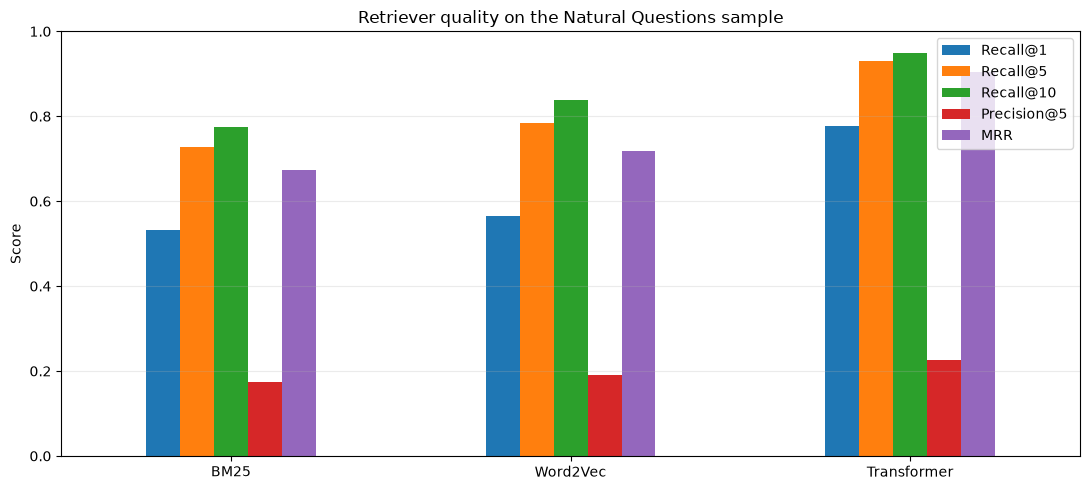

In [7]:
all_metrics = {
    'BM25': bm25_metrics,
    'Word2Vec': word2vec_metrics,
    'Transformer': transformer_metrics,
}
comparison = pd.DataFrame(all_metrics).T
display(comparison.style.format('{:.3f}').highlight_max(axis=0, color='#b7e4c7'))

comparison.plot(kind='bar', ylim=(0, 1), figsize=(11, 5), rot=0)
plt.title('Retriever quality on the Natural Questions sample')
plt.ylabel('Score')
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

In [8]:
result_sets = {'BM25': bm25_results, 'Word2Vec': word2vec_results, 'Transformer': transformer_results}
rows = []
for query_id, query in enumerate(query_texts[:8]):
    relevant = set(qrels[query_id])
    for method, results in result_sets.items():
        top_three = results[query_id][:3]
        rows.append({
            'query': query, 'method': method, 'top_3_document_ids': top_three,
            'relevant_in_top_3': sorted(relevant.intersection(top_three)),
        })
pd.DataFrame(rows)

print('Best method by metric:')
for metric in comparison.columns:
    winner = comparison[metric].idxmax()
    print(f'  {metric}: {winner} ({comparison.loc[winner, metric]:.4f})')

Best method by metric:
  Recall@1: Transformer (0.7760)
  Recall@5: Transformer (0.9298)
  Recall@10: Transformer (0.9497)
  Precision@5: Transformer (0.2263)
  MRR: Transformer (0.9044)


## Transformer embedding-space visualization

PCA projects transformer embeddings for sampled Natural Questions queries and one known-relevant document per query into two dimensions. A query (`Q`) appearing near its matching relevant document (`D`) suggests that the model places semantically related text close together. PCA necessarily loses information, so this plot is an intuitive view of clustering rather than a replacement for the quantitative retrieval metrics above.

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

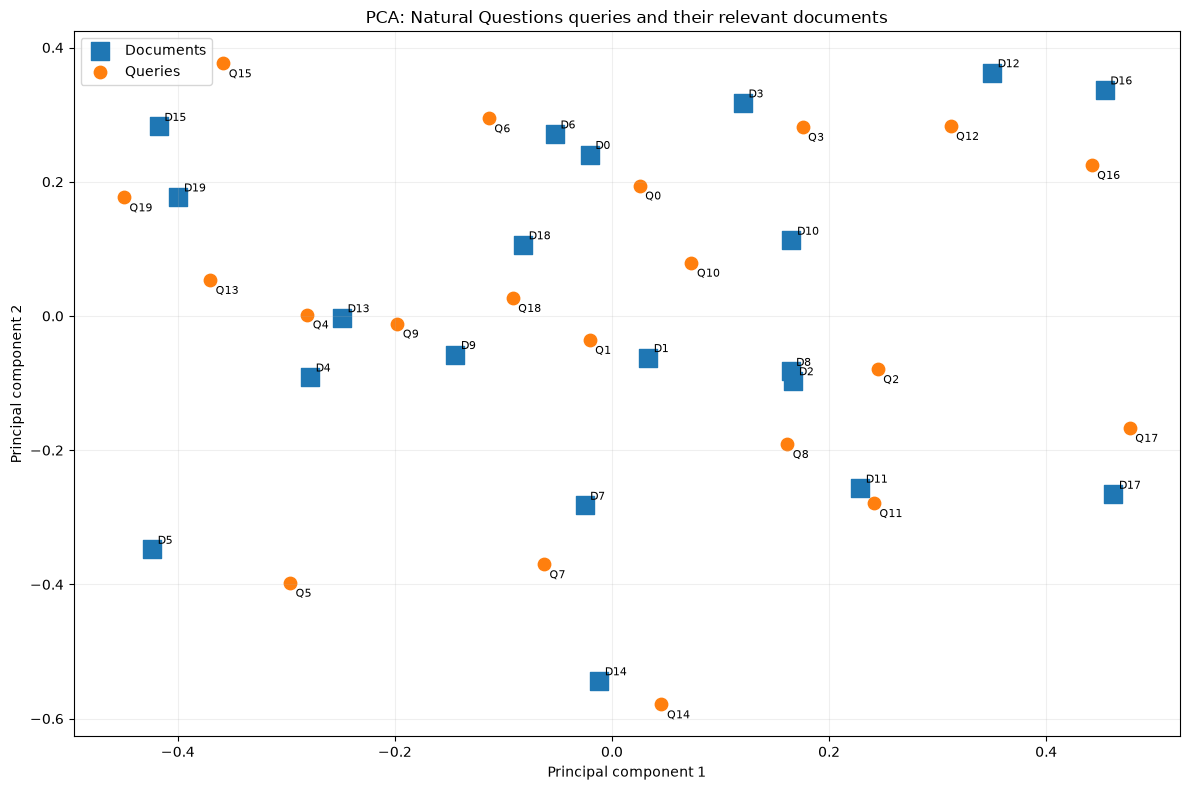

In [9]:
plot_query_ids = list(qrels)[:20]
plot_queries = [query_texts[qid] for qid in plot_query_ids]
plot_doc_ids = [next(iter(qrels[qid])) for qid in plot_query_ids]
plot_doc_embeddings = transformer.corpus_embeddings[plot_doc_ids]
query_embeddings = transformer.model.encode(
    plot_queries, convert_to_numpy=True, normalize_embeddings=True
)
combined = np.vstack([plot_doc_embeddings, query_embeddings])
points_2d = PCA(n_components=2).fit_transform(combined)
doc_points = points_2d[:len(plot_doc_ids)]
query_points = points_2d[len(plot_doc_ids):]

plt.figure(figsize=(12, 8))
plt.scatter(doc_points[:, 0], doc_points[:, 1], s=150, marker='s', label='Documents')
plt.scatter(query_points[:, 0], query_points[:, 1], s=80, marker='o', label='Queries')
for pair_id, (x, y) in enumerate(doc_points):
    plt.annotate(f'D{pair_id}', (x, y), xytext=(4, 4), textcoords='offset points', fontsize=8)
for pair_id, (x, y) in enumerate(query_points):
    plt.annotate(f'Q{pair_id}', (x, y), xytext=(4, -10), textcoords='offset points', fontsize=8)
plt.title('PCA: Natural Questions queries and their relevant documents')
plt.xlabel('Principal component 1')
plt.ylabel('Principal component 2')
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## The retriever's role in RAG

A Retrieval-Augmented Generation system first encodes or scores a user's question, retrieves the most relevant documents, and adds those documents to the generator model's prompt. The language model then writes an answer grounded in that supplied evidence. Retrieval expands the generator's effective knowledge beyond its training data, while citations and constrained prompting can make answers easier to verify. The included Streamlit app runs all three retrievers over the same corpus and can pass each method's retrieved context to a generator, making the effect of retrieval quality directly visible.

This retrieve–augment–generate pattern underlies search-grounded assistants and coding or research tools such as ChatGPT, Copilot, and Perplexity, though production systems also add access control, reranking, source attribution, freshness checks, and safety layers. A retriever cannot guarantee factual answers: if it misses the needed evidence, the generator cannot reliably recover it.

The comparison illustrates the evolution of retrieval. **BM25** is fast and interpretable and excels when queries share distinctive terms with documents, but it cannot naturally connect paraphrases. **Word2Vec** adds word-level semantic similarity, yet every word has a single context-independent vector and averaging loses word order; it also needs enough domain text to learn useful relationships. **Transformer sentence embeddings** represent whole passages contextually and usually handle paraphrases and intent best, at the cost of model latency and memory. In practice, strong RAG systems often combine BM25 and dense retrieval, then rerank the merged candidates.